In [1]:
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
img_array = cv2.imread("Train_Dataset/Closed_Eyes/s0001_00056_0_0_0_0_0_01.png", cv2.IMREAD_GRAYSCALE)

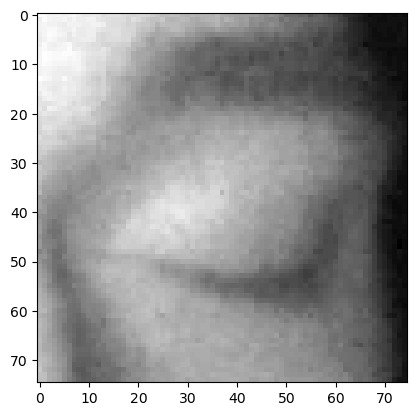

In [3]:
plt.imshow(img_array, cmap="gray")

In [4]:
img_array.shape

(75, 75)

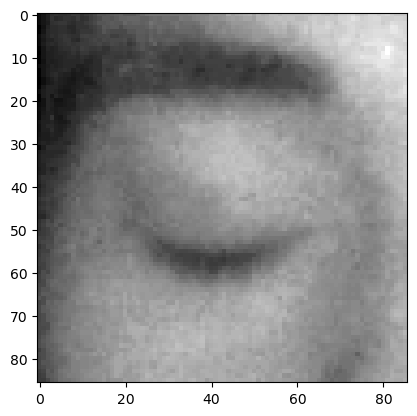

In [5]:
Datadirectory = "Train_Dataset/"
classes = ["Closed_Eyes", "Open_Eyes"]

for category in classes:
    path = os.path.join(Datadirectory, category) #path = Train_Dataset/Closed_Eyes
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        backtorgb = cv2.cvtColor(img_array, cv2.COLOR_GRAY2BGR)
        plt.imshow(img_array, cmap="gray")
        plt.show()
        break
    break

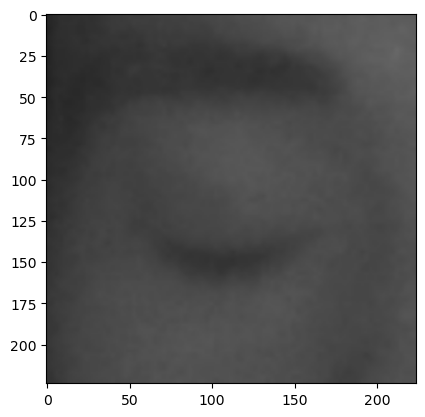

In [6]:
img_size = 224

new_array = cv2.resize(backtorgb, (img_size, img_size))
plt.imshow(new_array, cmap="gray")
plt.show()

# reading all the images and converting them into an array for data and labels

In [7]:
training_Data = []
classes = ["Closed_Eyes", "Open_Eyes"]

def create_training_Data():
    for category in classes:
        path = os.path.join(Datadirectory, category)
        class_numm = classes.index(category) # 0 or 1
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE) #read image
                backtorgb = cv2.cvtColor(img_array, cv2.COLOR_GRAY2BGR)
                new_array = cv2.resize(backtorgb, (img_size, img_size))
                training_Data.append([new_array, class_numm])
            except Exception as e:
                pass

In [8]:
create_training_Data()

In [9]:
len(training_Data)

65588

# Each batch from train_ds already contains: (images, labels)

In [10]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Train_Dataset",          # dataset folder
    image_size=(224,224),
    batch_size=32,
    validation_split=0.1,
    subset="training",
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Train_Dataset",
    image_size=(224,224),
    batch_size=32,
    validation_split=0.1,
    subset="validation",
    seed=123
)

Found 65588 files belonging to 2 classes.
Using 59030 files for training.
Found 65588 files belonging to 2 classes.
Using 6558 files for validation.


In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [12]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels)

(32, 224, 224, 3)
tf.Tensor([0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 1 0 0 0 1 0 1 0 1 1 0 0 0 0 1], shape=(32,), dtype=int32)


In [13]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Test_Dataset",   # separate folder (VERY IMPORTANT)
    image_size=(224,224),
    batch_size=32,
    shuffle=False     # don't shuffle → needed for evaluation
)

Found 16396 files belonging to 2 classes.


In [14]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


# tf.keras.preprocessing.image_dataset_from_directory() directly reads images from the folder in batches.

# --> deep learning model for training - Transfer Learning

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [16]:
tempmodel = tf.keras.applications.mobilenet.MobileNet()

In [17]:
# tempmodel.summary()

# --> Transfer Learning

In [18]:
base_input = tempmodel.input ## input

In [19]:
base_output = tempmodel.layers[-4].output ## output

In [20]:
Flat_layer = layers.Flatten()(base_output)
output = layers.Dense(1)(Flat_layer) ## one node (1 or 0)
final_output = layers.Activation("sigmoid")(output)

In [21]:
model = keras.Model(inputs = base_input, outputs = final_output)

# --> Settings for binary classification (open/ closed)

In [22]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# --> training

In [23]:
model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 3882s 2s/step - accuracy: 0.9632 - loss: 0.0964 - val_accuracy: 0.9677 - val_loss: 0.0719
Epoch 2/10
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 3850s 2s/step - accuracy: 0.9716 - loss: 0.0704 - val_accuracy: 0.9756 - val_loss: 0.0588
Epoch 3/10
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 3801s 2s/step - accuracy: 0.9747 - loss: 0.0624 - val_accuracy: 0.9738 - val_loss: 0.0574
Epoch 4/10
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 3792s 2s/step - accuracy: 0.9779 - loss: 0.0551 - val_accuracy: 0.9776 - val_loss: 0.0617
Epoch 5/10
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 3749s 2s/step - accuracy: 0.9807 - loss: 0.0480 - val_accuracy: 0.9806 - val_loss: 0.0574
Epoch 6/10
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 3713s 2s/step - accuracy: 0.9840 - loss: 0.0399 - val_accuracy: 0.9806 - val_loss: 0.0467
Epoch 7/10
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 3711s 2s/step - accuracy: 0.9861 - loss: 0.0327 - val_accuracy: 0.9809 - val_loss: 0.0505
Epoch 8/10
1845/1845 ━━━━━━━━━━━━━━━━━━━━ 3710s 2s/step - accuracy: 0.9895 -

In [24]:
model.save('model.keras')

In [25]:
model = tf.keras.models.load_model("model.keras")

# checking the model predictions

In [26]:
img_array = cv2.imread("test1.png", cv2.IMREAD_GRAYSCALE)
backtorgb = cv2.cvtColor(img_array, cv2.COLOR_GRAY2RGB)
new_array = cv2.resize(backtorgb, (img_size,img_size))

In [27]:
X_input = np.array(new_array).reshape(1, img_size, img_size, 3)

In [28]:
X_input.shape

(1, 224, 224, 3)

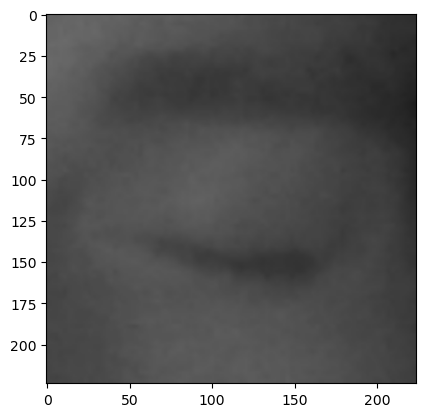

In [29]:
plt.imshow(new_array)

In [30]:
X_input = X_input/255.0

In [31]:
prediction = model.predict(X_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step


In [32]:
print(prediction)

[[1.7424553e-09]]


In [33]:
if prediction > 0.5:
    print("Open eyes")
else:
    print("Closed eyes")

Closed eyes


# Checking for unknown image

In [34]:
img = cv2.imread("test_img.jpg")

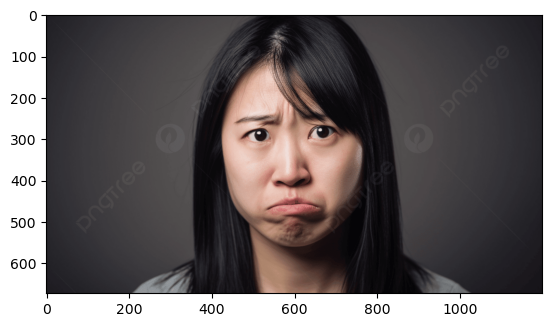

In [35]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [36]:
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades+"haarcascade_frontalface_default.xml")

In [37]:
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades+"haarcascade_eye.xml")

In [38]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [39]:
eyes = eye_cascade.detectMultiScale(gray,1.1, 4)

In [40]:
for(x, y, w, h) in eyes:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

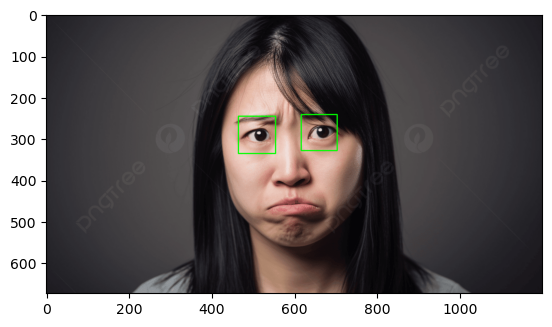

In [41]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Cropping the eye image

In [42]:
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades+"haarcascade_eye.xml")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
eyes = eye_cascade.detectMultiScale(gray,1.1, 4)

for(x, y, w, h) in eyes:
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]
    eyess = eye_cascade.detectMultiScale(roi_gray)
    if len(eyess) == 0:
        print("eyes are not detected")
    else:
        for (ex, ey, ew, eh) in eyess:
            eyes_roi = roi_color[ey: ey+eh, ex:ex+ew]

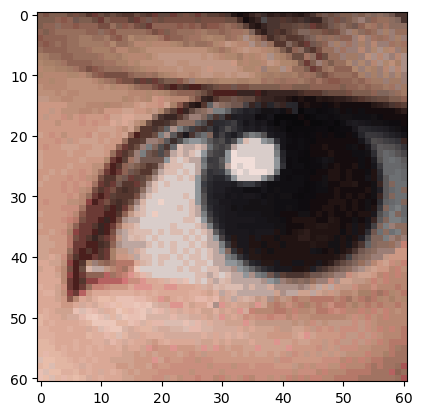

In [43]:
plt.imshow(cv2.cvtColor(eyes_roi, cv2.COLOR_BGR2RGB))

In [44]:
eyes_roi.shape

(61, 61, 3)

In [45]:
final_image = cv2.resize(eyes_roi, (224, 224))
final_image = np.expand_dims(final_image, axis=0) ## need fourth dimension
final_image = final_image/255.0

In [46]:
final_image.shape

(1, 224, 224, 3)

In [47]:
value = model.predict(final_image)
print(value)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[0.96600914]]


In [48]:
if value > 0.5:
    print("Open eyes")
else:
    print("Closed eyes")

Open eyes


In [49]:
train_loss, train_acc = model.evaluate(train_ds)
print("Train Accuracy:", train_acc)
print("Train Loss:", train_loss)

1845/1845 ━━━━━━━━━━━━━━━━━━━━ 660s 357ms/step - accuracy: 0.9912 - loss: 0.0236
Train Accuracy: 0.9911909103393555
Train Loss: 0.023623976856470108


In [50]:
val_loss, val_acc = model.evaluate(val_ds)
print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

205/205 ━━━━━━━━━━━━━━━━━━━━ 73s 356ms/step - accuracy: 0.9812 - loss: 0.0809
Validation Accuracy: 0.9812442660331726
Validation Loss: 0.08090590685606003


In [51]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

513/513 ━━━━━━━━━━━━━━━━━━━━ 195s 379ms/step - accuracy: 0.9789 - loss: 0.0832
Test Accuracy: 0.9788972735404968
Test Loss: 0.08324708044528961
